# Project Setup

This is a personal project by Bryan Beus -- https://bluesanta.io -- to explore effective and ineffective Kickstarter campaigns, with regards to data analytics and machine learning.

In this particular notebook, we'll import our wrangled dataset, explore the data and create visualizations, then store the data in a new parquet file that we can use in the next stage of the project.

In [7]:
# Common DataFrame Tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Python Libraries
from datetime import datetime
import json
from wordcloud import WordCloud, STOPWORDS

In [2]:
df = pd.read_parquet('../../metadata/01-ksr-metadata.parquet', engine='pyarrow')

In [3]:
df.head(2)

,id,name,blurb,goal,pledged,state,slug,country,country_displayable_name,currency,...,category.id,category.name,category.analytics_name,category.slug,category.position,category.parent_id,category.parent_name,category.color,urls.web.project,creator.is_ksr_admin
0,1703332404,Massage By Donation... Seriously!,Physical wellness is not a luxury; it is a nec...,53170.0,52.0,failed,massage-by-donation-seriously,US,the United States,USD,...,395,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/pressurem...,False
1,1704943227,eifel-abenteuer.de - Nachhaltige Outdoorangebo...,Aufbau eines erlebnispädagogischen Outdoorakti...,10000.0,0.0,failed,eifel-abenteuerde-nachhaltige-outdoorangebote-...,DE,Germany,EUR,...,271,Live Games,Live Games,games/live games,2,12.0,Games,51627,https://www.kickstarter.com/projects/eifel-abe...,False


# Creating Visualizations -- Column by Column

We're going to go through the dataset, column by column, and see what kinds of questions and visualizations we can create as we gain familiarity with this dataset.

In [4]:
col_list = df.columns

## Preliminary Wordcloud

In [12]:
start_pos = 0
end_pos = 3
print(col_list[start_pos:end_pos])

Index(['id', 'name', 'blurb'], dtype='object')


The first three columns are descriptive. We could take a look real quick at common word themes.

In [8]:
text = " ".join(blurb for blurb in df["blurb"].dropna().astype(str))

In [9]:
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color="white", 
    stopwords=STOPWORDS
).generate(text)

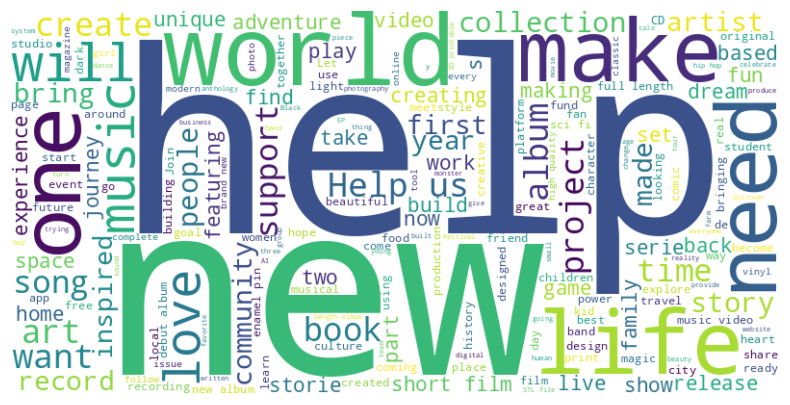

In [11]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hides the x and y axis lines
plt.savefig('./eda-data-visualizations/02-00-data-vis-wordcloud')
plt.show()

Notable words from our wordcloud are:

- help
- new
- world
- need
- make
- life
- will
- music
- one

The wordcloud seems fitting, given the nature of Kickstarter.

## Goals, Pledges, and Results

These two columns are among the most important of columns in our dataset. We will return to these throughout our analysis.

The `state` column holds the results, and this is likely to be the target column when we begin making predictions. 

In [13]:
df['state'].value_counts()

state
successful    64801
failed        32026
canceled       3661
live           3392
Name: count, dtype: int64

For the sake of simplicity, we will only look at `successful` and `failed` campaigns.

We won't factor in currency yet.

In [21]:
temp_df_success = df[df['state'] == 'successful']
temp_df_fail = df[df['state'] == 'failed']

In [22]:
temp_df_success['state'].value_counts()

state
successful    64801
Name: count, dtype: int64

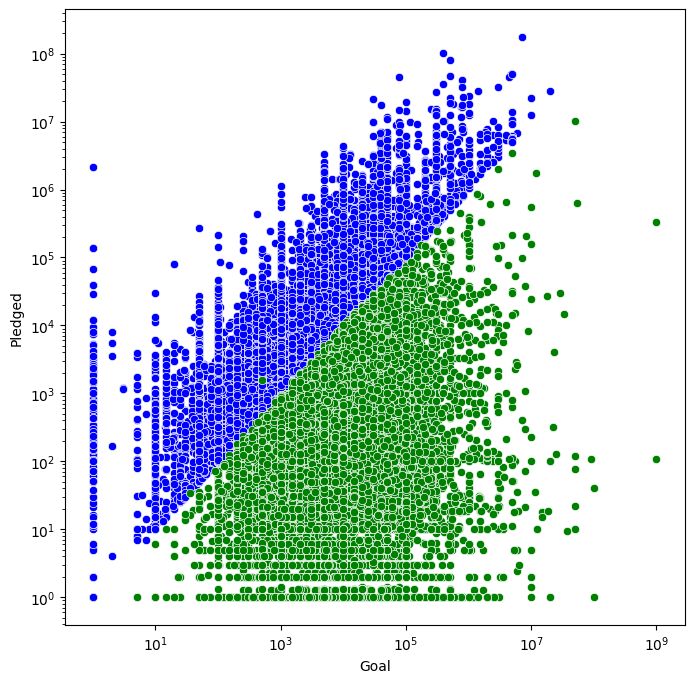

In [28]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(data=temp_df_success, x='goal', y='pledged', color='blue', ax=ax)
sns.scatterplot(data=temp_df_fail, x='goal', y='pledged', color='green', ax=ax)
#sns.lmplot(data=temp_df_success, x='goal', y='pledged', line_kws={'color': 'g'}, ax=ax)
ax.set_xlabel('Goal')
ax.set_ylabel('Pledged')
plt.xscale('log')
plt.yscale('log')
plt.show()

Already, there are some interesting observations.

We note that both successful and failed campaigns spread evenly along a logarithmic scale.

On the upper side of the diagonal (primarily successful campaigns):
- There are a large number of projects that had a goal of `1.0` but managed to gather a significant sum of pledges.
- There are a few green dots among the blue dots. This suggests that these were projects that passed their goal, but still failed.
- There is a project at `10^7` that barely passed its goal.

On the lower side of the diagonal (failed campaigns):
- There are few projects that requested more than `$10` and did not succeed.
- Somewhere around `$100`, the failures begin in earnest.
- There is a horizontal bar of campaigns that made pledges up to `$10^8`, but received `$0` pledges.
- Two projects made a goal of `$10^9`. One earned only `$100`, but the other made a respectable effort at `$10^5`.

Let's investigate a few of these findings by searching for the project names and links.

In [42]:
temp_df = df[(df['goal'] == 1)]

In [43]:
temp_df.shape

(153, 54)

In [44]:
temp_df['state'].value_counts()

state
successful    143
canceled        5
failed          3
live            2
Name: count, dtype: int64

In [65]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None):
    print(temp_df[(temp_df['state'] == 'successful') & (temp_df['pledged'] > 10000)][['pledged', 'urls.web.project']].sort_values(by='pledged', ascending=False))

           pledged  \
74255   2149404.00   
23931    138067.00   
80041    138067.00   
57879     68764.10   
78750     39423.00   
79161     39423.00   
14798     28688.18   
18697     11867.00   
103899    11867.00   

                                                                                                urls.web.project  
74255                                  https://www.kickstarter.com/projects/artix/adventurequest-worlds-infinity  
23931        https://www.kickstarter.com/projects/thelongestjohns/voyage-new-album-campaign-by-the-longest-johns  
80041        https://www.kickstarter.com/projects/thelongestjohns/voyage-new-album-campaign-by-the-longest-johns  
57879                                    https://www.kickstarter.com/projects/lisaberry/re-covering-with-friends  
78750   https://www.kickstarter.com/projects/goodcompenny/let-me-hold-a-dolla-larussell-goes-majorly-independent  
79161   https://www.kickstarter.com/projects/goodcompenny/let-me-hold-a-dolla-larussell-g

The highest winner on this list, AdventureQuest Worlds, achieved this status as recently as the week before this essay (August 6, 2026).

Here's a list of the three projects that had a goal of `$1`, but did not succeed.

In [52]:
with pd.option_context('display.width', None):
    print(temp_df[temp_df['state'] == 'failed'][['name', 'urls.web.project']])

                                            name  \
63445   Custom Birdhouses made by Nathan Loppnow   
65108                            The Old Country   
100606                       A Moral Guide to...   

                                         urls.web.project  
63445   https://www.kickstarter.com/projects/158466416...  
65108   https://www.kickstarter.com/projects/dreamcrew...  
100606  https://www.kickstarter.com/projects/369830203...  


The first and third projects are still live on the website, while the second has been removed.

The author of the first one re-ran the campaign and was successful the second time around.

Let's take a look at some of the campaigns on the highest end, including those that only just met their goals.

In [125]:
temp_df = df[(df['goal'] > 10 ** 6.75) & (df['state'] == 'successful')]

In [126]:
temp_df.shape

(5, 54)

In [127]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None, 'display.float_format', lambda x: '%.0f' % x):
    print(temp_df[(temp_df['state'] == 'successful')][['pledged', 'urls.web.project']].sort_values(by='pledged', ascending=False))

        pledged  \
19050 175553524   
3789   28596436   
19810  22315617   
2461   12664792   
25148   6784322   

                                                                                                 urls.web.project  
19050  https://www.kickstarter.com/projects/tasseidenki/gaime-plug-and-play-time-crisis-gun-system-for-modern-tvs  
3789                                                 https://www.kickstarter.com/projects/tinywonderstudio/korobo  
19810                                                   https://www.kickstarter.com/projects/483270682/fcgame-led  
2461                    https://www.kickstarter.com/projects/awesome0920/tonin-japanese-style-sci-fi-slash-action  
25148                     https://www.kickstarter.com/projects/locagames/volontes-otome-visual-novel-localization  


The highest funded campaign was a video-game gun for modern devices, similar to the original Ninentendo gun for games like Duck Hunt.

At this point, we note that campaign currency is becoming relevant. 

For example, the above project is counted in Japanese Yen. Right now, `$1 USD` exchanges for approximately `153 YEN`, making the numbers confusing.

Let's restrict our dataset to projects with USD currency at this time.

In [130]:
temp_df = df[(df['goal'] > 10 ** 6.75) & (df['state'] == 'successful') & (df['currency'] == 'USD')]

In [131]:
temp_df.shape

(0, 54)

Immediately, we can see a huge difference. Let's lower the threshold.

In [132]:
temp_df = df[(df['goal'] > 10 ** 6) & (df['state'] == 'successful') & (df['currency'] == 'USD')]

In [133]:
temp_df.shape

(6, 54)

In [134]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None, 'display.float_format', lambda x: '%.0f' % x):
    print(temp_df[(temp_df['state'] == 'successful')][['pledged', 'urls.web.project']].sort_values(by='pledged', ascending=False))

       pledged  \
95305  6519020   
96233  5764229   
4152   5702153   
3893   3105473   
1238   1911827   
3126   1418910   

                                                                       urls.web.project  
95305                          https://www.kickstarter.com/projects/mst3k/makemoremst3k  
96233                         https://www.kickstarter.com/projects/mst3k/bringbackmst3k  
4152     https://www.kickstarter.com/projects/559914737/the-veronica-mars-movie-project  
3893                  https://www.kickstarter.com/projects/1869987317/wish-i-was-here-1  
1238       https://www.kickstarter.com/projects/773106364/blue-mountain-state-the-movie  
3126   https://www.kickstarter.com/projects/spikelee/the-newest-hottest-spike-lee-joint  


The highest ranked project here is the famous Mystery Science Theater 3000, which had a goal of `$2M` and raised an impressive `$6.5M`.

Let's take a look at some of the projects that passed their goal, but still failed.

In [135]:
temp_df = df[(df['state'] == 'failed') & (df['pledged'] > df['goal']) & (df['currency'] == 'USD')]

In [136]:
temp_df.shape

(1, 54)

In [137]:
temp_df.head()

,id,name,blurb,goal,pledged,state,slug,country,country_displayable_name,currency,...,category.id,category.name,category.analytics_name,category.slug,category.position,category.parent_id,category.parent_name,category.color,urls.web.project,creator.is_ksr_admin
76203,1880688778,Off Grid Mobile Mesh Network,A must have in your outdoor survivalist backpa...,500.0,1551.0,failed,off-grid-mobile-mesh-network,US,the United States,USD,...,334,DIY Electronics,DIY Electronics,technology/diy electronics,4,16.0,Technology,6526716,https://www.kickstarter.com/projects/824280148...,False


An off-grid mobile nesh network for `$500`. Interesting. 

Let's see if we can see why this project failed.

In [141]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None, 'display.float_format', lambda x: '%.0f' % x):
    print(temp_df[['disable_communication', 'urls.web.project']])

       disable_communication  \
76203                  False   

                                                                  urls.web.project  
76203  https://www.kickstarter.com/projects/824280148/off-grid-mobile-mesh-network  


This seems to be some kind of anomaly. 

The project received `$1551` in backers, according to the website, which is hgiher than the `$500` goal. 

There are only a few backers. 

We may consider simply dropping this from the dataset.

In [150]:
temp_id_val = temp_df.iloc[0]['id']

In [151]:
df.shape

(103880, 54)

In [ ]:
df[df['id'] == temp_id_val].value_counts()

In [152]:
df = df.drop(df[df['id'] == temp_id_val].index)

In [153]:
df.shape

(103879, 54)

Let's take a look at some of the most ambitious projects that received `$0` pledges.

In [159]:
temp_df = df[(df['currency'] == 'USD') & (df['state'] == 'failed') & (df['goal'] > 10**6.5) & (df['pledged'] == 0)]

In [160]:
temp_df.shape

(15, 54)

In [162]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None, 'display.float_format', lambda x: '%.0f' % x):
    print(temp_df[['goal', 'urls.web.project']].sort_values(by='goal', ascending=False))

           goal  \
97557  52000000   
30396  50000000   
39571  30000000   
82641  25000000   
37179  22000000   
66771  22000000   
29131  10000000   
79173  10000000   
5881    9000000   
43801   9000000   
80856   8000000   
47299   5000000   
106211  5000000   
33946   4000000   
80546   4000000   

                                                                                                  urls.web.project  
97557                                   https://www.kickstarter.com/projects/silverscreenvideo/silver-screen-video  
30396                   https://www.kickstarter.com/projects/2055389152/the-cultivator-episode-1-lord-of-the-gorgs  
39571                            https://www.kickstarter.com/projects/384925467/secure-spent-nuclear-fuel-rods-now  
82641             https://www.kickstarter.com/projects/heptagon/creating-an-unbiased-news-and-advertising-platform  
37179   https://www.kickstarter.com/projects/basketmap/basketmap-turn-by-turn-store-navigation-that-saves-you-

The highest project set a goal of `$52M`. The idea was to create a multi-episode sitcom.

The next highest project was similar, with the basis of the show being a comic book series by the author.

Let's take a look at the failed campaigns with the highest goal amounts.

In [163]:
temp_df = df[(df['state'] == 'failed') & (df['goal'] > 10**8)]

In [164]:
temp_df.shape

(3, 54)

In [165]:
with pd.option_context('display.width', None, 'display.max_rows', None, 'display.max_colwidth', None, 'display.float_format', lambda x: '%.0f' % x):
    print(temp_df[['goal', 'urls.web.project']].sort_values(by='goal', ascending=False))

             goal  \
89370  1000000000   
101636 1000000000   
87229   120773000   

                                                                                                      urls.web.project  
89370       https://www.kickstarter.com/projects/kyozofuruhashi/japanese-anime-auspiciousness-meditative-visualization  
101636                                                      https://www.kickstarter.com/projects/kojitamura/secondwave  
87229   https://www.kickstarter.com/projects/wakaba1890hagakure/hagakurehub-the-master-collection-and-manga-revolution  


All three were story ideas that did not receive sufficient support.

## Countries and Currencies

In [170]:
pos_start = df.columns.get_loc('state') + 1
pos_end = pos_start + 6
df.iloc[:, pos_start:pos_end].head()

,slug,country,country_displayable_name,currency,currency_symbol,currency_trailing_code
0,massage-by-donation-seriously,US,the United States,USD,$,True
1,eifel-abenteuerde-nachhaltige-outdoorangebote-...,DE,Germany,EUR,€,False
2,graphic-novel-pachacuti,IT,Italy,EUR,€,False
3,madeintuskegee-pop-up-shops-and-open-air-court...,US,the United States,USD,$,True
4,goddesses-in-everywoman,US,the United States,USD,$,True


Let's see which countries were the most popular.

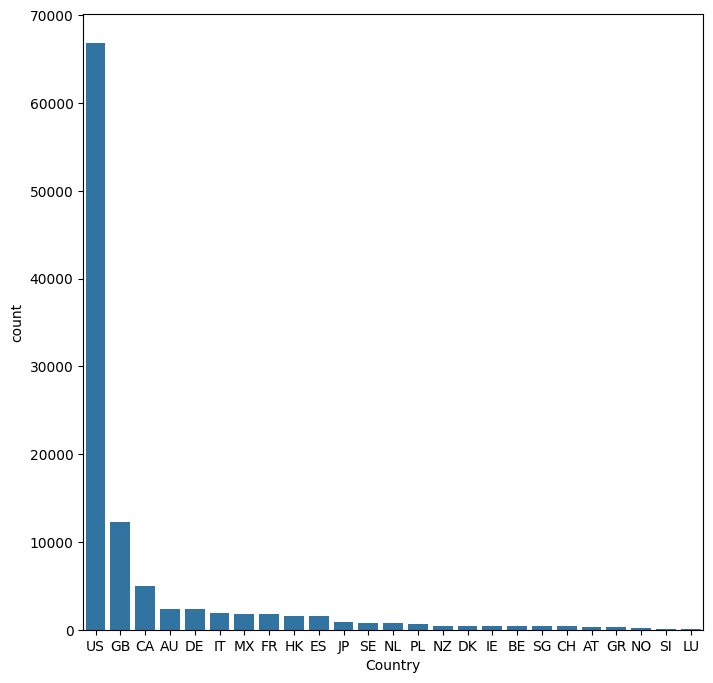

In [174]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.countplot(
    data=df,
    x='country',
    ax=ax,
    order=df['country'].value_counts().index
)
ax.set_xlabel('Country')
plt.show()

The USA, Great Britain, and Canada are the leaders.

Australia, Germany (Deutschland), and Italy follow after.

Let's see who else uses `USD` as a currency for these projects.

In [178]:
temp_df = df[(df['currency'] == 'USD') & (df['country'] != 'US')]

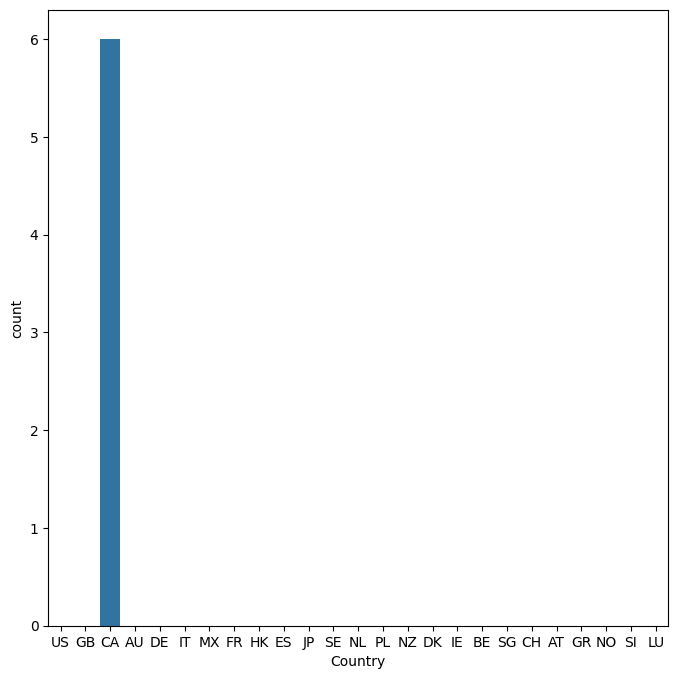

In [179]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.countplot(
    data=temp_df,
    x='country',
    ax=ax,
    order=df['country'].value_counts().index
)
ax.set_xlabel('Country')
plt.show()

It looks like Canada is the only other country.

Let's investigate the dataset to find the highest valued successful project for each country, converting the pledges to USD for comparison.

First, we'll look through the columns to see which columns already provide us with this information.

In [180]:
df.columns

Index(['id', 'name', 'blurb', 'goal', 'pledged', 'state', 'slug', 'country',
       'country_displayable_name', 'currency', 'currency_symbol',
       'currency_trailing_code', 'deadline', 'state_changed_at', 'created_at',
       'launched_at', 'staff_pick', 'disable_communication', 'backers_count',
       'static_usd_rate', 'usd_pledged', 'converted_pledged_amount', 'fx_rate',
       'usd_exchange_rate', 'current_currency', 'usd_type', 'spotlight',
       'percent_funded', 'is_launched', 'creator.id', 'creator.name',
       'creator.has_admin_message_badge', 'creator.partner_badge',
       'creator.ppo_has_action', 'creator.backing_action_count', 'location.id',
       'location.name', 'location.short_name', 'location.displayable_name',
       'location.localized_name', 'location.country', 'location.state',
       'location.type', 'location.expanded_country', 'category.id',
       'category.name', 'category.analytics_name', 'category.slug',
       'category.position', 'category.parent_i

In [187]:
df[(df['currency'] != 'USD') & (df['pledged'] != 0)][['country','currency','usd_exchange_rate', 'current_currency', 'usd_type', 'fx_rate','goal', 'pledged', 'usd_pledged', 'converted_pledged_amount']].head()

,country,currency,usd_exchange_rate,current_currency,usd_type,fx_rate,goal,pledged,usd_pledged,converted_pledged_amount
2,IT,EUR,1.083199,USD,domestic,1.138244,2500.0,34.0,35.07186632,36.0
7,ES,EUR,1.036185,USD,domestic,1.138244,52600.0,40.0,42.0933884,41.0
10,GB,GBP,1.244493,USD,domestic,1.331437,4700.0,754.0,958.31093514,938.0
12,CA,CAD,0.705990,USD,domestic,0.710374,1000.0,1475.0,1080.711968,1041.0
14,DE,EUR,1.169566,USD,domestic,1.138244,30.0,120.0,141.4438824,140.0


After a little bit of Google research, the best column to use here is simply `converted_pledged_amount`.

We could also use `usd_pledged`. The difference is unclear on Google. They appear to be the same in concept, but the values are different. The `converted_pledged_amount` seems to be based on an exchange-rate API.

In [195]:
temp_df = df.groupby('country_displayable_name')['converted_pledged_amount'].mean().sort_values(ascending=False)

In [196]:
temp_df.head(3)

country_displayable_name
Hong Kong      86087.868590
Singapore      21077.226221
Switzerland    20095.131926
Name: converted_pledged_amount, dtype: float64

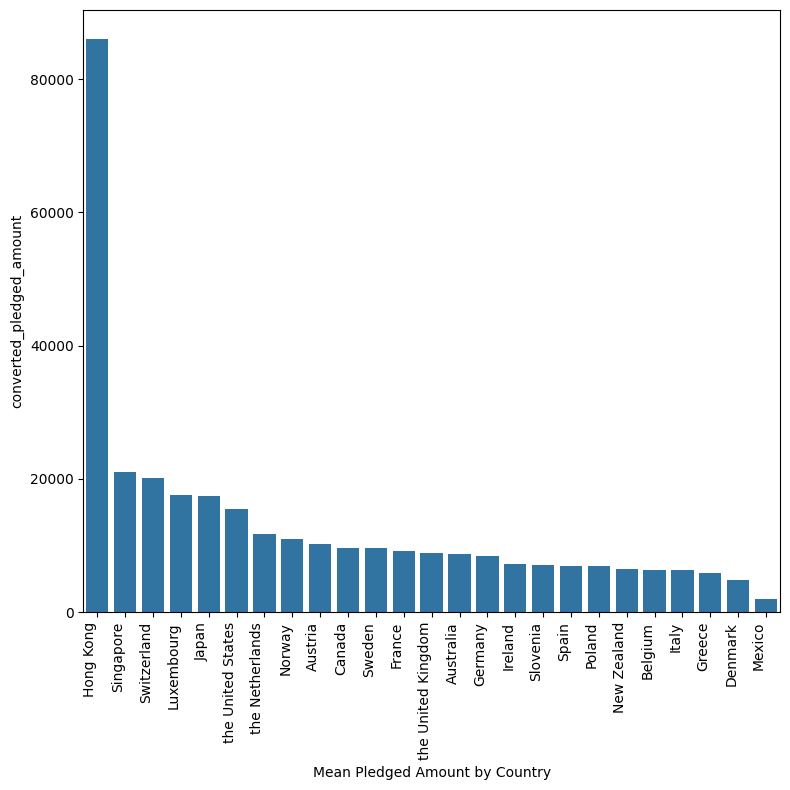

In [201]:
fig, ax = plt.subplots(figsize=(8,8))
sns.barplot(data=temp_df, ax=ax)
ax.set_xlabel('Mean Pledged Amount by Country')
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

Amazingly, Hong Kong dominates. Let's take a look at specifics.

In [202]:
temp_df = df[df['country'] == 'HK']

In [203]:
temp_df.shape

(1560, 54)

In [205]:
temp_df[temp_df['state'] == 'successful'].shape

(1203, 54)

In [237]:
size_bins = [0, 100, 1000, 2500, 5000, 7500, 10000, 25000, 50000, 75000, 100000, 250000, 500000, 750000, 1000000, 5000000, 10000000, 14000000]

In [238]:
temp_count = pd.cut(temp_df['converted_pledged_amount'], bins=size_bins)

In [239]:
temp_count.value_counts().shape

(17,)

In [240]:
pd.DataFrame(temp_count.value_counts())

,count
converted_pledged_amount,
"(10000, 25000]",286
"(100, 1000]",184
"(25000, 50000]",154
"(2500, 5000]",130
"(100000, 250000]",123
"(1000, 2500]",118
"(0, 100]",107
"(5000, 7500]",107
"(50000, 75000]",100


The highest valued Hong Kong project came in at `$13.3M`.

Let's create bins to see the overall spread

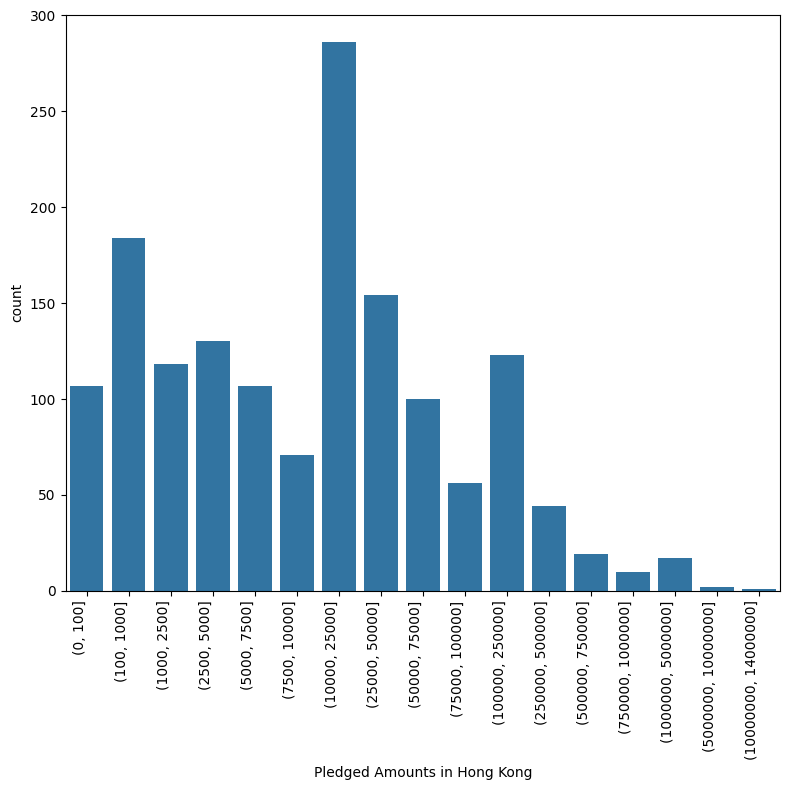

In [241]:
fig, ax = plt.subplots(figsize=(8,8))
sns.barplot(data=temp_count.value_counts(), ax=ax)
ax.set_xlabel('Pledged Amounts in Hong Kong')
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

Interestingly, the most frequent outcome of pledges is between `$10000` and `$25000`, followed by small projects between `$100` and `$1000`.